### **SPAM/HAM Email Classifier using SVM Exercise Classical approach Bag-of-words**

This notebook implements a spam email classifier using Support Vector Machines (SVM) with a Bag of Words model.
To compare with the SVM implementation there are some alternative classifiers created.

#### **Table of Contents**
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Feature Engineering](#3-feature-engineering)
4. [Bag of Words Model](#4-bag-of-words-model)
5. [Data Preprocessing](#5-data-preprocessing)
6. [SVM Model Training](#6-svm-model-training)
7. [Model Evaluation](#7-model-evaluation)

#### **Summary**

This notebook implemented a SPAM/HAM email classifier using:

1. **Feature Engineering**: Custom features based on word frequencies, character counts, and text statistics
2. **Bag of Words**: TF-IDF vectorization with unigrams and bigrams
3. **SVM Classifier**: Linear kernel SVM with class weight balancing

The model was evaluated using cross-validation and a held-out validation set before generating predictions on the test set.

#### **Potential Improvements:**
- Experiment with different SVM kernels (RBF, polynomial)
- Try different feature engineering approaches
- Use ensemble methods
- Tune hyperparameters with grid search
- Add more domain-specific features

This version has a naive SVM(), and the final result is 72%.  There is no hyperparameter optimization
  


#### **1. Setup and Imports**

In [31]:
# Standard library imports
import os
import re
import glob
from collections import defaultdict

# Data manipulation
import numpy as np
import pandas as pd

# Machine learning
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")

All imports successful!


#### **2. Data Loading and Exploration**

In [32]:
# Define data paths
BASE_DIR = 'data/'
SPAM_DIR = BASE_DIR + 'spam/'
HAM_DIR = BASE_DIR + 'ham/'
TEST_DIR = BASE_DIR + 'test/'

# Count files in each directory
spam_files = glob.glob(SPAM_DIR + '*.txt')
ham_files = glob.glob(HAM_DIR + '*.txt')
test_files = [TEST_DIR + str(x) + '.txt' for x in range(1000)]  # Test files are numbered 0-999

print(f"Number of SPAM emails: {len(spam_files)}")
print(f"Number of HAM emails: {len(ham_files)}")
print(f"Number of TEST emails: {len(test_files)}")
print(f"\nTotal training emails: {len(spam_files) + len(ham_files)}")

Number of SPAM emails: 1200
Number of HAM emails: 2971
Number of TEST emails: 1000

Total training emails: 4171


In [33]:
def read_email(filepath):
    """Read email content from a file."""
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return ""

In [34]:
# Sample a SPAM email
print("=" * 50)
print("SAMPLE SPAM EMAIL:")
print("=" * 50)
print(read_email(spam_files[0])[:500])

SAMPLE SPAM EMAIL:
Subject: tdk cd labeling kit @ $ 12 . 00
cd
labeling kit
$ 12 . 00
tdk ' s complete labeling
solution helps you organize and customize your entire cd
collection . - create your own layouts or choose from
a multitude of backgrounds . - one step easy - to - use
label applicator . just peel , place and press . -
assures accurate placement of label onto cd . - same
size as a standard jewel case for easy storage . -
includes patented label applicator , tdk labeling
software for pc and 50 blank white 


In [35]:
# Sample a HAM email
print("=" * 50)
print("SAMPLE HAM EMAIL:")
print("=" * 50)
print(read_email(ham_files[0])[:500])

SAMPLE HAM EMAIL:
Subject: fw : monday evening ' s gas flow
daren ,
the below memo was rec ' d on today from my contact at lyondell ( john allen )
referencing meter 98 - 1063 ' s gas pressure problems on last night ( 3 - 7 - 00 ) .
i thought that this might be some useful information to you .
thanks
- jackie -
3 - 9497
- - - - - - - - - - - - - - - - - - - - - - forwarded by jackie young / hou / ect on 03 / 07 / 2000 11 : 15
am - - - - - - - - - - - - - - - - - - - - - - - - - - -
" allen , john s . " on 03 / 07 


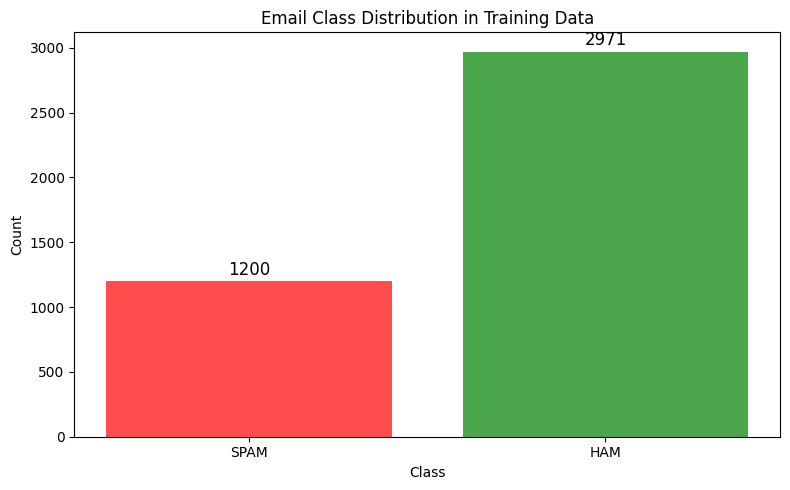

In [36]:
# Visualize class distribution
labels = ['SPAM', 'HAM']
counts = [len(spam_files), len(ham_files)]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['red', 'green'], alpha=0.7)
plt.title('Email Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

#### **3. Feature Engineering**

We will create custom features based on the structure in `featurize.py` plus additional features that may help classify spam vs ham emails.

In [37]:
# ============================================================
# WORD-BASED FEATURES (from featurize.py)
# ============================================================

def freq_word_feature(word):
    """Factory function to create word frequency features."""
    def feature(text, freq):
        return float(freq[word])
    return feature

# Common spam indicator words
SPAM_WORDS = [
    'pain', 'private', 'bank', 'money', 'drug', 'spam', 'prescription',
    'creative', 'height', 'featured', 'differ', 'width', 'other', 'energy',
    'business', 'message', 'volumes', 'revision', 'path', 'meter', 'memo',
    'planning', 'pleased', 'record', 'out', 'free', 'click', 'offer',
    'winner', 'urgent', 'viagra', 'pills', 'casino', 'lottery', 'prize',
    'credit', 'income', 'save', 'discount', 'deal', 'limited', 'act',
    'now', 'cash', 'earn', 'million', 'rich', 'cheap', 'buy', 'order'
]

In [38]:
# ============================================================
# CHARACTER-BASED FEATURES
# ============================================================

def freq_char_feature(char):
    """Factory function to create character count features."""
    def feature(text, freq):
        return text.count(char)
    return feature

# Special characters often found in spam
SPECIAL_CHARS = [';', '$', '#', '!', '(', '[', '&', '@', '%', '*', '?']

In [39]:
# ============================================================
# CUSTOM FEATURES (Additional spam indicators)
# ============================================================

def has_html_tags(text, freq):
    """Check for HTML tags (common in spam)."""
    return int(bool(re.search(r'<[^>]+>', text)))

def count_urls(text, freq):
    """Count number of URLs in the email."""
    return len(re.findall(r'http[s]?://|www\.', text))

def count_uppercase_words(text, freq):
    """Count words in ALL CAPS (common in spam)."""
    words = re.findall(r'\b[A-Z]{2,}\b', text)
    return len(words)

def avg_word_length(text, freq):
    """Calculate average word length."""
    words = re.findall(r'\w+', text)
    if len(words) == 0:
        return 0
    return sum(len(w) for w in words) / len(words)

def count_numbers(text, freq):
    """Count numbers in the email."""
    return len(re.findall(r'\d+', text))

def text_length(text, freq):
    """Total length of the email."""
    return len(text)

def word_count(text, freq):
    """Total number of words."""
    return len(re.findall(r'\w+', text))

def count_lines(text, freq):
    """Count number of lines."""
    return text.count('\n')

def has_subject(text, freq):
    """Check if email has a Subject line."""
    return int('subject:' in text.lower())

def exclamation_ratio(text, freq):
    """Ratio of exclamation marks to text length."""
    if len(text) == 0:
        return 0
    return text.count('!') / len(text) * 100

def uppercase_ratio(text, freq):
    """Ratio of uppercase characters."""
    if len(text) == 0:
        return 0
    upper = sum(1 for c in text if c.isupper())
    return upper / len(text) * 100

def digit_ratio(text, freq):
    """Ratio of digits to text length."""
    if len(text) == 0:
        return 0
    digits = sum(1 for c in text if c.isdigit())
    return digits / len(text) * 100

In [40]:
# ============================================================
# FEATURE VECTOR GENERATION
# ============================================================

def generate_feature_vector(text, freq):
    """Generate a feature vector for a given email."""
    features = []
    
    # Word frequency features
    for word in SPAM_WORDS:
        features.append(float(freq[word]))
    
    # Character frequency features
    for char in SPECIAL_CHARS:
        features.append(text.count(char))
    
    # Custom features
    features.append(has_html_tags(text, freq))
    features.append(count_urls(text, freq))
    features.append(count_uppercase_words(text, freq))
    features.append(avg_word_length(text, freq))
    features.append(count_numbers(text, freq))
    features.append(text_length(text, freq))
    features.append(word_count(text, freq))
    features.append(count_lines(text, freq))
    features.append(has_subject(text, freq))
    features.append(exclamation_ratio(text, freq))
    features.append(uppercase_ratio(text, freq))
    features.append(digit_ratio(text, freq))
    
    return features

# Feature names for reference
FEATURE_NAMES = (
    SPAM_WORDS + 
    [f'char_{c}' for c in SPECIAL_CHARS] +
    ['has_html', 'url_count', 'caps_words', 'avg_word_len', 'number_count',
     'text_length', 'word_count', 'line_count', 'has_subject',
     'exclamation_ratio', 'uppercase_ratio', 'digit_ratio']
)

print(f"Total number of custom features: {len(FEATURE_NAMES)}")

Total number of custom features: 73


In [41]:
def generate_design_matrix(filenames, verbose=True):
    """Generate design matrix from email files."""
    design_matrix = []
    texts = []
    
    for i, filename in enumerate(filenames):
        if verbose and i % 500 == 0:
            print(f"Processing file {i}/{len(filenames)}...")
        
        text = read_email(filename)
        if not text:
            continue
            
        text_clean = text.replace('\r\n', ' ')
        texts.append(text_clean)
        
        # Create word frequency dictionary
        words = re.findall(r'\w+', text_clean.lower())
        word_freq = defaultdict(int)
        for word in words:
            word_freq[word] += 1
        
        # Generate feature vector
        feature_vector = generate_feature_vector(text_clean, word_freq)
        design_matrix.append(feature_vector)
    
    if verbose:
        print(f"Done! Processed {len(design_matrix)} emails.")
    
    return np.array(design_matrix), texts

#### **4. Bag of Words Model**

We will create a Bag of Words representation using scikit-learn's `CountVectorizer`.

In [42]:
# Load all email texts
print("Loading SPAM emails...")
spam_texts = [read_email(f) for f in spam_files]
spam_texts = [t.replace('\r\n', ' ') for t in spam_texts if t]

print("Loading HAM emails...")
ham_texts = [read_email(f) for f in ham_files]
ham_texts = [t.replace('\r\n', ' ') for t in ham_texts if t]

print("Loading TEST emails...")
test_texts = [read_email(f) for f in test_files]
test_texts = [t.replace('\r\n', ' ') for t in test_texts]

# Combine training texts
all_train_texts = spam_texts + ham_texts

print(f"\nTotal training texts: {len(all_train_texts)}")
print(f"Total test texts: {len(test_texts)}")

Loading SPAM emails...
Loading HAM emails...
Loading TEST emails...

Total training texts: 4171
Total test texts: 1000


In [43]:
# Create Bag of Words model using CountVectorizer
print("Creating Bag of Words model...")

# Using TF-IDF which often works better than raw counts
vectorizer = TfidfVectorizer(
    max_features=5000,       # Limit vocabulary size
    min_df=2,                # Ignore terms that appear in fewer than 2 documents
    max_df=0.95,             # Ignore terms that appear in more than 95% of documents
    stop_words='english',    # Remove common English stop words
    ngram_range=(1, 2),      # Use unigrams and bigrams
    lowercase=True
)

# Fit on training data and transform
X_bow_train = vectorizer.fit_transform(all_train_texts)
X_bow_test = vectorizer.transform(test_texts)

print(f"BoW Training matrix shape: {X_bow_train.shape}")
print(f"BoW Test matrix shape: {X_bow_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Creating Bag of Words model...
BoW Training matrix shape: (4171, 5000)
BoW Test matrix shape: (1000, 5000)
Vocabulary size: 5000


In [44]:
# Show top words in vocabulary
feature_names = vectorizer.get_feature_names_out()
print("Sample vocabulary words:")
print(feature_names[:20])

Sample vocabulary words:
['00' '00 00' '00 20' '00 25' '00 31' '00 32' '00 463' '00 60' '00 90'
 '00 daren' '00 deal' '00 deliveries' '00 nomination' '00 pm' '00 price'
 '00 production' '000' '000 00' '000 000' '000 day']


#### **5. Data Preprocessing**

Combine custom features with Bag of Words features and prepare the data for training.

In [45]:
# Generate custom features
print("Generating custom features for SPAM emails...")
X_custom_spam, _ = generate_design_matrix(spam_files)

print("\nGenerating custom features for HAM emails...")
X_custom_ham, _ = generate_design_matrix(ham_files)

print("\nGenerating custom features for TEST emails...")
X_custom_test, _ = generate_design_matrix(test_files)

Generating custom features for SPAM emails...
Processing file 0/1200...
Processing file 500/1200...
Processing file 1000/1200...
Done! Processed 1200 emails.

Generating custom features for HAM emails...
Processing file 0/2971...
Processing file 500/2971...
Processing file 1000/2971...
Processing file 1500/2971...
Processing file 2000/2971...
Processing file 2500/2971...
Done! Processed 2971 emails.

Generating custom features for TEST emails...
Processing file 0/1000...
Processing file 500/1000...
Done! Processed 1000 emails.


In [46]:
# Combine custom features
X_custom_train = np.vstack([X_custom_spam, X_custom_ham])

print(f"Custom features training shape: {X_custom_train.shape}")
print(f"Custom features test shape: {X_custom_test.shape}")

Custom features training shape: (4171, 73)
Custom features test shape: (1000, 73)


In [47]:
# Combine BoW features with custom features
from scipy.sparse import hstack, csr_matrix

# Convert custom features to sparse matrix
X_custom_train_sparse = csr_matrix(X_custom_train)
X_custom_test_sparse = csr_matrix(X_custom_test)

# Combine features
X_train_combined = hstack([X_bow_train, X_custom_train_sparse])
X_test_combined = hstack([X_bow_test, X_custom_test_sparse])

print(f"Combined training features shape: {X_train_combined.shape}")
print(f"Combined test features shape: {X_test_combined.shape}")

Combined training features shape: (4171, 5073)
Combined test features shape: (1000, 5073)


In [48]:
# Create labels: 1 for SPAM, 0 for HAM
y_train = np.array([1] * len(spam_texts) + [0] * len(ham_texts))

print(f"Training labels shape: {y_train.shape}")
print(f"Class distribution: SPAM={sum(y_train==1)}, HAM={sum(y_train==0)}")

Training labels shape: (4171,)
Class distribution: SPAM=1200, HAM=2971


In [49]:
# Split training data for validation
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_combined, y_train, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 3336
Validation set size: 835


#### **6. SVM Model Training**

In [50]:
# Train a basic SVM model
print("Training SVM model...")

svm_model = SVC()

svm_model.fit(X_train, y_train_split)
print("Training complete!")
print(f"Accuracy on Training split: {svm_model.score(X_train, y_train_split):.4f}")

Training SVM model...
Training complete!
Accuracy on Training split: 0.7161


In [51]:
# Cross-validation on the full training set
print("Performing 5-fold cross-validation...")

cv_scores = cross_val_score(
    SVC(),
    X_train_combined, y_train, 
    cv=5, 
    scoring='accuracy'
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Performing 5-fold cross-validation...

Cross-validation scores: [0.71856287 0.71342926 0.7146283  0.7146283  0.71582734]
Mean CV accuracy: 0.7154 (+/- 0.0035)


#### **7. Model Evaluation**

In [52]:
# Evaluate on validation set
y_val_pred = svm_model.predict(X_val)

print("Validation Set Performance:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['HAM', 'SPAM']))

Validation Set Performance:
Accuracy: 0.7210

Classification Report:
              precision    recall  f1-score   support

         HAM       0.72      0.99      0.84       595
        SPAM       0.71      0.05      0.09       240

    accuracy                           0.72       835
   macro avg       0.71      0.52      0.46       835
weighted avg       0.72      0.72      0.62       835



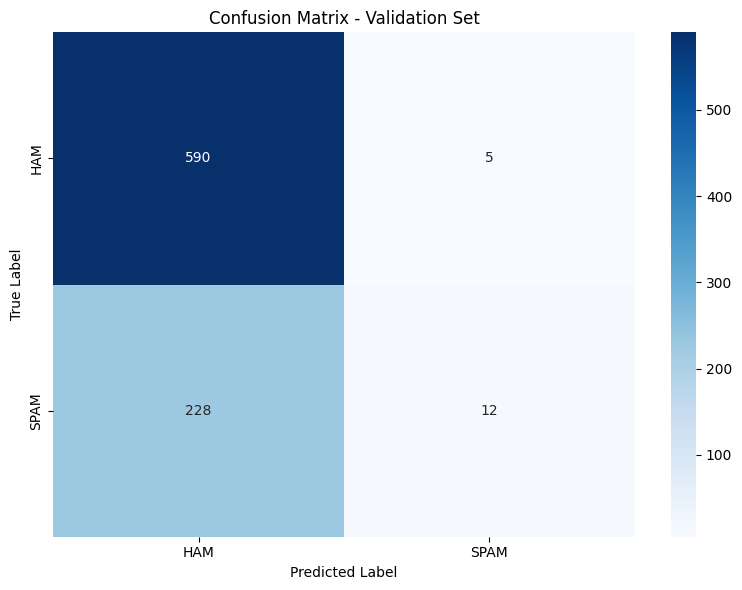

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HAM', 'SPAM'],
            yticklabels=['HAM', 'SPAM'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [54]:
# Train final model on ALL training data
print("Training final model on all training data...")

final_svm = SVC()

final_svm.fit(X_train_combined, y_train)
print("Final model trained!")

Training final model on all training data...
Final model trained!


#### **8. Test Predictions and Submission**

In [55]:
# Generate predictions on test set
print("Generating predictions on test set...")
y_test_pred = final_svm.predict(X_test_combined)

print(f"Test predictions shape: {y_test_pred.shape}")
print(f"Predicted SPAM: {sum(y_test_pred == 1)}")
print(f"Predicted HAM: {sum(y_test_pred == 0)}")

Generating predictions on test set...
Test predictions shape: (1000,)
Predicted SPAM: 13
Predicted HAM: 987


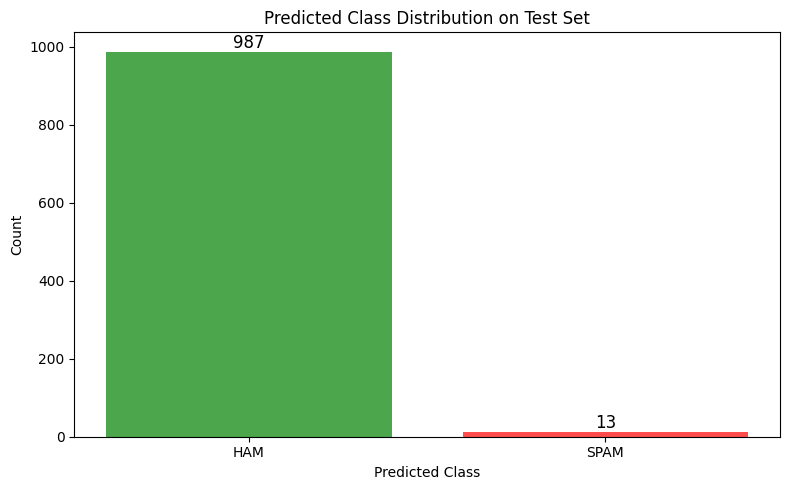

In [56]:
# Visualize test predictions distribution
plt.figure(figsize=(8, 5))
labels = ['HAM', 'SPAM']
counts = [sum(y_test_pred == 0), sum(y_test_pred == 1)]
plt.bar(labels, counts, color=['green', 'red'], alpha=0.7)
plt.title('Predicted Class Distribution on Test Set')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
# Save predictions to CSV using the save_csv snippet
def results_to_csv(y_test, file_name):
    """Save predictions to Kaggle-accepted CSV format."""
    y_test = y_test.astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1  # Kaggle expects 1-indexed IDs
    df.to_csv(file_name, index_label='Id')
    print(f"Predictions saved to {file_name}")
    return df

In [58]:
# Create submission file
from datetime import datetime

ts = datetime.now().strftime("%Y-%m-%d-%H-%M")
sub_name = 'submission'+ts+'.csv'
submission_df = results_to_csv(y_test_pred, sub_name)

# Display first few rows
print('Submission file generated as', sub_name)
print("\nSubmission file preview:")
print(submission_df.head(10))

Predictions saved to submission2026-04-19-10-47.csv
Submission file generated as submission2026-04-19-10-47.csv

Submission file preview:
    Category
1          0
2          0
3          0
4          0
5          0
6          0
7          0
8          0
9          0
10         0


In [59]:
# Verify the submission file

print("\nSubmission file verification:")
verify_df = pd.read_csv(sub_name)
print(f"Shape: {verify_df.shape}")
print(f"Columns: {verify_df.columns.tolist()}")
print(f"\nValue counts:")
print(verify_df['Category'].value_counts())


Submission file verification:
Shape: (1000, 2)
Columns: ['Id', 'Category']

Value counts:
Category
0    987
1     13
Name: count, dtype: int64
